# 1. Introduction

## a. Five examples of ML applications
1. Spam detection — binary classification. It automatically filters large volumes of email.
2. Apartment price prediction — regression. It helps buyers and sellers estimate a fair price.
3. Product recommendations — ranking/association. They help users find relevant products and improve sales.
4. Bank fraud detection — anomaly detection or binary classification. It helps prevent financial losses.
5. Customer segmentation — clustering. It helps companies personalize products and communication.

## b.
- Predict house price — regression.
- Predict whether a client returns a loan — binary classification.
- Predict when a patient needs to take medicine — regression if an exact time is predicted, or classification if time intervals are used.
- Choose which medicine a patient should take — multiclass classification.
- Choose a client segment for promotion — multiclass classification; the segments themselves can first be found using clustering.
- Recognize defective products from photos — binary classification.
- Decide how to place products on a shelf — association-rule learning or optimization.
- Search websites for a text query — ranking; it can be formulated as regression by predicting a relevance score.
- Split store customers into behavioral segments — clustering.
- Detect anomalies in site traffic — anomaly detection or binary classification if labels are available.
The five examples from part (a) are classified directly in their descriptions.

## c.
In multiclass classification, each object belongs to exactly one of several classes. In multilabel classification, one object may belong to several classes at the same time.

## d.
House-price prediction is a regression problem because the target is a continuous numerical value. It can be reduced to classification by dividing prices into intervals such as low, medium, and high, but this loses information about the exact price.
    

# 2. Introduction to Data Analysis

In [239]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

import lightgbm
import scipy
import statsmodels


In [240]:
df = pd.read_json("./data/train.json")
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [241]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 49352
Columns: 15


In [242]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

Target is price

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [244]:
df.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

In [245]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


The dataset contains 49,352 rows and 15 columns. There are no missing values in any column. The median listing has one bedroom and one bathroom; 75% of listings have no more than two bedrooms and one bathroom. The maximum values of eight bedrooms and ten bathrooms are rare and should be inspected as possible outliers. Price is strongly right-skewed: its median is 3,150, while the mean is 3,830 and the maximum is 4,490,000.

In [246]:
df[["bathrooms", "bedrooms", "price"]].corr()

,bathrooms,bedrooms,price
bathrooms,1.000000,0.533446,0.069661
bedrooms,0.533446,1.000000,0.051788
price,0.069661,0.051788,1.000000


Before removing price outliers, bathrooms and bedrooms have weak positive Pearson correlations with price (0.070 and 0.052). These values are distorted by extreme prices, so they should not be interpreted as evidence that rooms are unimportant. Bedrooms and bathrooms have a moderate positive correlation of 0.533: listings with more bedrooms generally have more bathrooms.

In [247]:
df = df[["bathrooms", "bedrooms", "interest_level", "price"]]
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## Target analysis

<Axes: >

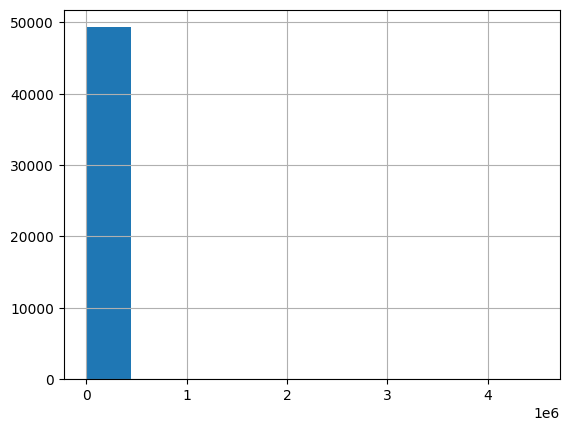

In [248]:
df["price"].hist()

The histogram is compressed near zero because price has a long right tail and a few extremely large values. Most listings cannot be examined clearly on this scale.

<Axes: >

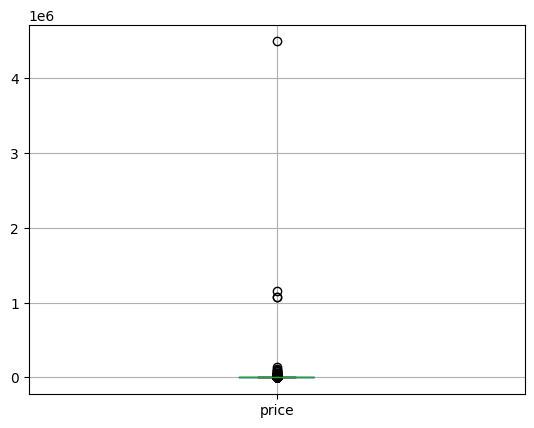

In [249]:
df[["price"]].boxplot()


The boxplot confirms that price has many high-value outliers. The maximum price is far above the central 50% of the data, so it distorts both the histogram and summary statistics such as the mean and standard deviation.

In [250]:
lower = df["price"].quantile(0.01)
upper = df["price"].quantile(0.99)

df_filtered = df[df["price"].between(lower, upper)].copy()

<Axes: >

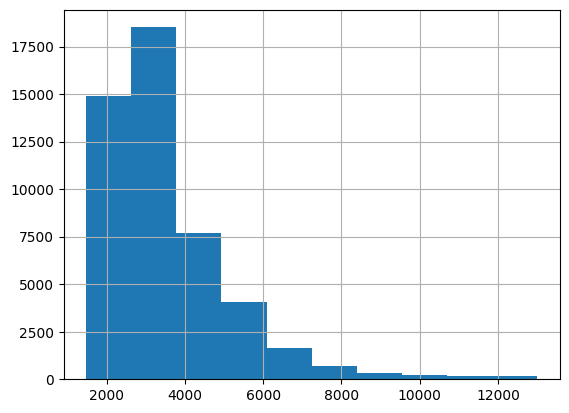

In [251]:
df_filtered["price"].hist()

After keeping prices between the 1st and 99th percentiles, the main part of the distribution becomes visible. Most rental prices are concentrated in the lower part of the retained range, and the distribution remains right-skewed rather than normal.

## Characteristics Analysis

In [252]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  object 
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.8+ MB


In [253]:
df_filtered["interest_level"].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [254]:
interest_mapping = {"low": 0, "medium": 1, "high": 2}
df_filtered["interest_level"] = df_filtered["interest_level"].map(interest_mapping)
df_filtered.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795


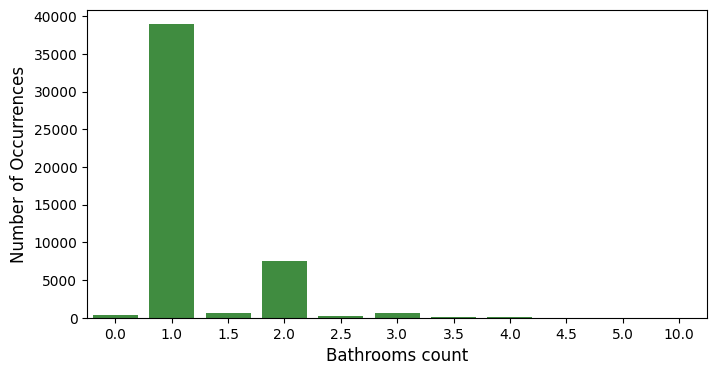

In [255]:
int_bathrooms = df_filtered["bathrooms"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=int_bathrooms.index, y=int_bathrooms.values, alpha=0.8, color="green")
plt.ylabel("Number of Occurrences", fontsize=12)
plt.xlabel("Bathrooms count", fontsize=12)
plt.show()

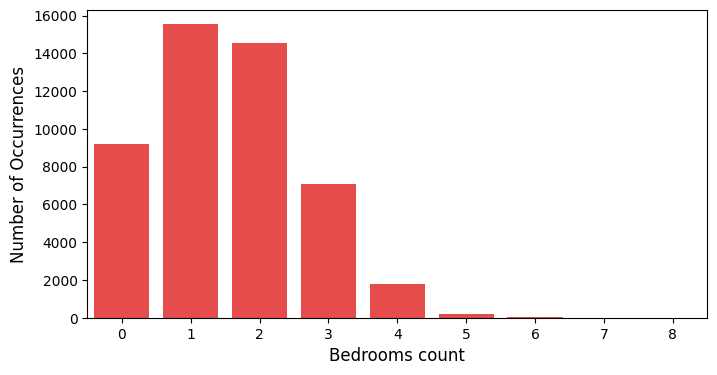

In [256]:
int_bedrooms = df_filtered["bedrooms"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=int_bedrooms.index, y=int_bedrooms.values, alpha=0.8, color="red")
plt.ylabel("Number of Occurrences", fontsize=12)
plt.xlabel("Bedrooms count", fontsize=12)
plt.show()

The features are discrete and strongly imbalanced: most listings have one bathroom and zero to three bedrooms. Very rare values such as ten bathrooms or seven to eight bedrooms are potential statistical outliers, but rarity alone does not prove a data error; the corresponding listings should be inspected before removal.

In [257]:
df_filtered.loc[df_filtered[df_filtered["bedrooms"] >= 7].index]

,bathrooms,bedrooms,interest_level,price
11313,4.0,8,0,6500
28722,3.0,8,0,9995
104687,3.0,7,1,6923


## Complex analysis

In [258]:
corr_matrix = df_filtered.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


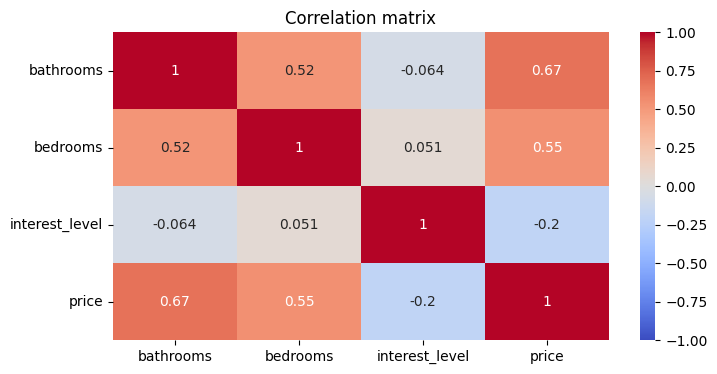

In [259]:
plt.figure(figsize=(8, 4))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

Price has a moderate positive correlation with the number of bathrooms and bedrooms. Interest level has a weak negative correlation with price: more expensive apartments generally receive lower interest.

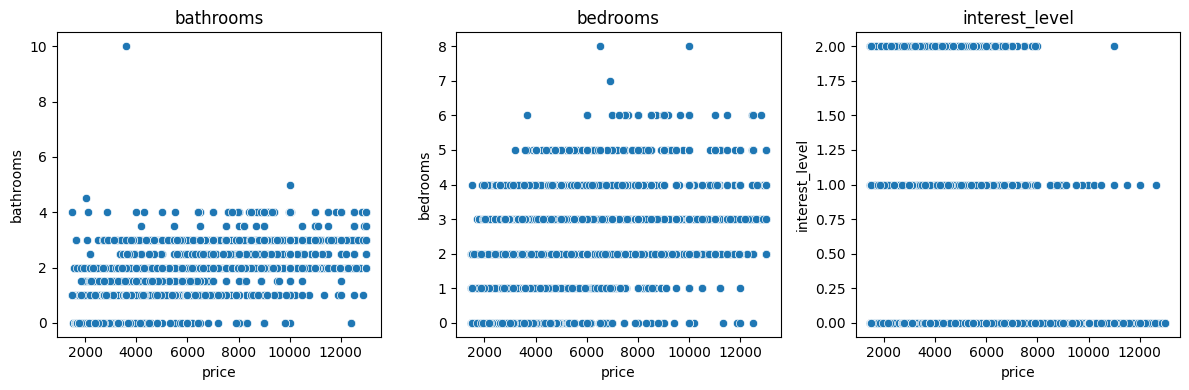

In [260]:
features = ["bathrooms", "bedrooms", "interest_level"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

for feature, ax in zip(features, axes):
    sns.scatterplot(data=df_filtered, x="price", y=feature, ax=ax)
    ax.set_title(f"{feature}")
    ax.set_xlabel("price")

plt.tight_layout()
plt.show()


## 4. Creating Features

In [261]:
df_filtered["bathrooms_squared"] = np.square(df_filtered["bathrooms"])
df_filtered["bedrooms_squared"] = np.square(df_filtered["bedrooms"])
df_filtered["interest_level_squared"] = np.square(df_filtered["interest_level"])

In [262]:
corr_matrix_squared = df_filtered.corr()
corr_matrix_squared

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,-0.063635,0.671943,0.956023,0.548760,-0.059410
bedrooms,0.517574,1.000000,0.050654,0.545948,0.478817,0.928277,0.039511
interest_level,-0.063635,0.050654,1.000000,-0.200111,-0.068558,0.046340,0.944013
price,0.671943,0.545948,-0.200111,1.000000,0.648486,0.543406,-0.182672
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486,1.000000,0.522227,-0.062240
bedrooms_squared,0.548760,0.928277,0.046340,0.543406,0.522227,1.000000,0.035718
interest_level_squared,-0.059410,0.039511,0.944013,-0.182672,-0.062240,0.035718,1.000000


Squared features are not more correlated with the target than the original features. Therefore, they do not provide an obvious improvement according to the correlation matrix.

In [263]:
X = df_filtered[["bathrooms", "bedrooms"]]
y = df_filtered["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 5. Fit Models

In [264]:
models = {
    "linear_regression": LinearRegression(),
    "decision_tree": DecisionTreeRegressor(random_state=21),
    "naive_mean": DummyRegressor(strategy="mean"),
    "naive_median": DummyRegressor(strategy="median"),
}

result_MAE = []
result_RMSE = []
train_predictions = pd.DataFrame(index=y_train.index)
test_predictions = pd.DataFrame(index=y_test.index)

for name, model in models.items():
    model.fit(X_train_poly, y_train)
    train_predictions[name] = model.predict(X_train_poly)
    test_predictions[name] = model.predict(X_test_poly)

    result_MAE.append({
        "model": name,
        "train": mean_absolute_error(y_train, train_predictions[name]),
        "test": mean_absolute_error(y_test, test_predictions[name]),
    })
    result_RMSE.append({
        "model": name,
        "train": root_mean_squared_error(y_train, train_predictions[name]),
        "test": root_mean_squared_error(y_test, test_predictions[name]),
    })

result_MAE = pd.DataFrame(result_MAE).round(2)
result_RMSE = pd.DataFrame(result_RMSE).round(2)

display(result_MAE)
display(result_RMSE)
print(f"Best by test MAE: {result_MAE.loc[result_MAE['test'].idxmin(), 'model']}")
print(f"Best by test RMSE: {result_RMSE.loc[result_RMSE['test'].idxmin(), 'model']}")

,train_mae,test_mae,train_rmse,test_rmse
lin_reg,756.73,759.83,1079.07,1247.30
dec_reg,756.70,753.99,1078.97,1073.88
navy_mean,1140.45,1136.62,1598.46,1594.39
navy_median,1087.46,1081.22,1645.46,1639.34


## Model comparison
The decision tree is the best model on the test set: it has the lowest MAE (753.99) and RMSE (1,073.88). Linear regression has a similar MAE (759.83), but its higher test RMSE (1,247.30) indicates several larger prediction errors. Both trained models clearly outperform the naive baselines. Among the baselines, the median gives a lower MAE because it is more robust to the right-skewed price distribution, whereas the mean gives a lower RMSE because squared error is minimized by the mean. The close train and test errors of the decision tree do not indicate strong overfitting in this experiment.